
**Start**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# CSV 파일 경로
csv_file = '/content/drive/MyDrive/converted_colors.csv'

# CSV 파일에서 데이터 읽기
df = pd.read_csv(csv_file, encoding='utf-8')

In [ ]:
# 데이터 확인
print(df.head())

                                           File Name  color  Color Index  Red  \
0  네이처리퍼블릭_허니멜팅립_쫀득복숭아.png    NaN            1  239   
1          더샘_새미스시럽샷멜팅밤_피치콧.png    NaN            1  237   
2               데이지크_멜팅캔디밤_누디피그.png    NaN            1  242   
3              데이지크_멜팅캔디밤_리치크림.png    NaN            1  234   
4           데이지크_멜팅캔디밤_스윗포멜로.png    NaN            1  253   

   Green  Blue Max Proportion      HEX   Price formulation  date  saturation  \
0    127   116        100.00%  #ef7f74  14,000         글로시    12          51   
1    133   115        100.00%  #ed8573  16,000         글로시    40          51   
2     99   111         63.11%  #f2636f  14,000         글로시    51          59   
3    102    98         92.79%  #ea6662  14,000         글로시    51          58   
4     97    89         66.25%  #fd6159  14,000         글로시    51          65   

   lightness    tone  
0         70  bright  
1         69  bright  
2         67  bright  
3         65  bright  
4         67  brigh

**사용자가 입력하는 제품 찾기**

In [ ]:
def find_tone(FileName, df):
    product_row = df[df['File Name'].str.lower() == FileName.lower()]
    if product_row.empty:
        raise ValueError(f"Product '{FileName}' not found in the dataset.")
    tone = product_row.iloc[0]['tone']
    return tone

In [ ]:
input_product = input("Enter the product name: ")

Enter the product name: 네이처리퍼블릭_허니멜팅립_쫀득복숭아.png


In [ ]:
input_name = '어뮤즈_듀밤_발레리나.png'
try:
    product_tone = find_tone(input_product, df)
    print(f"The tone of '{input_product}' is '{product_tone}'.")
except ValueError as e:
    print(e)

Product '네이처리퍼블릭_허니멜팅립_쫀득복숭아.png' not found in the dataset.



**다시 시작한다**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# CSV 파일 경로
csv_file = '/content/drive/MyDrive/converted_colors.csv'

# CSV 파일에서 데이터 읽기
df = pd.read_csv(csv_file, encoding='utf-8')

In [ ]:
# 데이터 확인
print(df.head())

                                           File Name  color  Color Index  Red  \
0  네이처리퍼블릭_허니멜팅립_쫀득복숭아.png    NaN            1  239   
1          더샘_새미스시럽샷멜팅밤_피치콧.png    NaN            1  237   
2               데이지크_멜팅캔디밤_누디피그.png    NaN            1  242   
3              데이지크_멜팅캔디밤_리치크림.png    NaN            1  234   
4           데이지크_멜팅캔디밤_스윗포멜로.png    NaN            1  253   

   Green  Blue Max Proportion      HEX   Price formulation  date  saturation  \
0    127   116        100.00%  #ef7f74  14,000         글로시    12          51   
1    133   115        100.00%  #ed8573  16,000         글로시    40          51   
2     99   111         63.11%  #f2636f  14,000         글로시    51          59   
3    102    98         92.79%  #ea6662  14,000         글로시    51          58   
4     97    89         66.25%  #fd6159  14,000         글로시    51          65   

   lightness    tone  
0         70  bright  
1         69  bright  
2         67  bright  
3         65  bright  
4         67  brigh

In [ ]:
from scipy.spatial.distance import euclidean

In [ ]:
def calculate_similarity(input_product, df):
    input_row = df[df['File Name'].str.lower() == input_product.lower()]
    if input_row.empty:
        raise ValueError(f"Product '{input_product}' not found in the dataset.")

    input_rgb = input_row.iloc[0]['Color RGB']

    # RGB 값으로 유클리드 거리 계산
    df['Distance'] = df['Color RGB'].apply(lambda x: euclidean(input_rgb, x))

    # 거리를 기준으로 정렬하여 반환
    return df.sort_values(by='Distance')

In [ ]:
input_idx = df[df['File Name'].str.lower() == input_product.lower()].index[0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
print(input_idx)

2


In [ ]:
# 텍스처 유사도 계산 (같으면 1, 다르면 0)
input_texture = df.loc[input_idx, 'formulation']
df['formulation Similarity'] = df['formulation'].apply(lambda x: 1 if x == input_texture else 0)

In [ ]:
# 톤 유사도 계산 (같으면 1, 다르면 0)
input_tone = df.loc[input_idx, 'tone']
df['tone Similarity'] = df['tone'].apply(lambda x: 1 if x == input_tone else 0)


In [ ]:
import numpy as np

def calculate_similarity(input_product, df):
    input_row = df[df['File Name'].str.lower() == input_product.lower()]
    if input_row.empty:
        raise ValueError(f"Product '{input_product}' not found in the dataset.")

    input_rgb = input_row.iloc[0]['Color RGB']

    # RGB 값으로 유클리드 거리 계산
    df['Color RGB'] = df['Color Code'].apply(lambda x: tuple(int(x[i:i+2], 16) for i in (1, 3, 5)))
    df['Distance'] = df['Color RGB'].apply(lambda x: euclidean(input_rgb, x))

    # 종합 유사도 계산 (가중합)
    df['Overall Similarity'] = (
        (1 - df['Distance'] / np.max(df['Distance'])) * 0.3 +
        df['formulation Similarity'] * 0.2 +
        df['tone Similarity'] * 0.1
    )

    return df.sort_values(by='Overall Similarity', ascending=False)


def recommend_products(input_product, df, num_recommendations=5):
    try:
        # 유사도 계산
        similarity_df = calculate_similarity(input_product, df)

        # 입력 제품 제외하고 유사도 높은 순으로 정렬
        recommendations = similarity_df[similarity_df['File Name'].str.lower() != input_product.lower()]
        return recommendations[['File Name', 'Overall Similarity']].head(num_recommendations)
    except IndexError:
        raise ValueError(f"Product '{input_product}' not found in the dataset.")

In [ ]:
print(df.head())

                                           File Name  color  Color Index  Red  \
0          클리오_크리스탈글래밤_꿀복숭아.png    NaN            1  254   
1  하트퍼센트_도트온무드듀이멜팅립스틱_듀이...    NaN            1   83   
2                         어뮤즈_듀밤_발레리나.png    NaN            1  244   
3    무지개맨션_무드웨어블러립스틱_레이어드.png    NaN            1  200   
4                   헤라_센슈얼누드밤_본프리.png    NaN            1  253   

   Green  Blue Max Proportion      HEX   Price formulation  date  saturation  \
0    219   220         53.65%  #fedbdc  18,000         글로시    25          14   
1     69    80        100.00%  #534550  15,000         글로시    54          17   
2    188   199         99.94%  #f4bcc7  20,000         글로시   123          23   
3    149   149         91.87%  #c89595  23,000          매트    53          25   
4    190   204        100.00%  #fdbecc  40,000         글로시   111          25   

   lightness          tone  
0         93           NaN  
1         30  dark_grayish  
2         85          pale  
3         6

In [ ]:
input_product = input("Enter the product name: ")

Enter the product name: 어뮤즈_듀밤_발레리나.png


In [ ]:
try:
    recommendations = recommend_products(input_product, df, num_recommendations=5)
    print("추천 제품:")
    print(recommendations)
except ValueError as e:
    print(e)

KeyError: 'Color RGB'

**2트**

In [1]:
import pandas as pd
from scipy.spatial.distance import euclidean
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# CSV 파일 경로
csv_file = '/content/drive/MyDrive/converted_colors.csv'

# CSV 파일에서 데이터 읽기
df = pd.read_csv(csv_file, encoding='utf-8')

In [13]:
# 데이터 확인
print(df.tail())

                                             File Name  color  Color Index  \
961     힌스_무드인핸서워터리퀴드글로우_엠비언트    NaN            1   
962  힌스_무드인핸서워터리퀴드글로우_인플루언스    NaN            1   
963       힌스_무드인핸서워터리퀴드글로우_체리쉬드    NaN            1   
964     힌스_무드인핸서워터리퀴드글로우_클래시컬    NaN            1   
965     힌스_무드인핸서워터리퀴드글로우_하모니어스    NaN            1   

     Red  Green  Blue Max Proportion      HEX   Price formulation  date  \
961  214     94    85        100.00%  #d65e55  19,000         글로시   143   
962  200     27    82         59.11%  #c81b52  19,000         글로시   143   
963  206     59    88        100.00%  #ce3b58  19,000         글로시   143   
964  154      8    29        100.00%  #9a081d  19,000         글로시   143   
965  192     65    58         56.36%  #c0413a  19,000         글로시   143   

     saturation  lightness    tone  
961          60         63  strong  
962          87         57   vivid  
963          71         59  strong  
964          95         45   vivid  
965          70    

In [18]:
# RGB 값 추출 및 유클리드 거리 계산
def calculate_rgb_similarity(input_product, df):
    input_row = df[df['File Name'].str.lower() == input_product.lower()]
    if input_row.empty:
        raise ValueError(f"Product '{input_product}' not found in the dataset.")

    input_rgb = input_row[['Red', 'Green', 'Blue']].values.flatten()
    df['Distance'] = df[['Red', 'Green', 'Blue']].apply(lambda x: euclidean(input_rgb, x), axis=1)
    return df

# Formulation과 Tone의 유사도 계산
def calculate_formulation_tone_similarity(input_product, df):
    input_row = df[df['File Name'].str.lower() == input_product.lower()]
    if input_row.empty:
        raise ValueError(f"Product '{input_product}' not found in the dataset.")

    input_formulation = input_row.iloc[0]['formulation']
    input_tone = input_row.iloc[0]['tone']
    df['formulation Similarity'] = df['formulation'].apply(lambda x: 1 if x == input_formulation else 0)
    df['tone Similarity'] = df['tone'].apply(lambda x: 1 if x == input_tone else 0)
    return df

# 종합 유사도 계산
def calculate_overall_similarity(df):
    df['Overall Similarity'] = (
        (1 - df['Distance'] / np.max(df['Distance'])) * 0.4 +
        df['formulation Similarity'] * 0.2 +
        df['tone Similarity'] * 0.4
    )
    return df.sort_values(by='Overall Similarity', ascending=False)

# 제품 추천 함수
def recommend_products(input_product, df, num_recommendations=5):
    try:
        df = calculate_rgb_similarity(input_product, df)
        df = calculate_formulation_tone_similarity(input_product, df)
        df = calculate_overall_similarity(df)

        recommendations = df[df['File Name'].str.lower() != input_product.lower()]
        return recommendations[['File Name', 'Overall Similarity']].head(num_recommendations)
    except ValueError as e:
        return str(e)

# 사용자 입력 받기
input_product = input("Enter the product name: ")


Enter the product name: 데이지크_쥬시듀이틴트_파파야밀크


In [19]:
# 제품 추천 실행
recommendations = recommend_products(input_product, df)
print("추천 제품:")
print(recommendations)

추천 제품:
Product '데이지크_쥬시듀이틴트_파파야밀크' not found in the dataset.


제품명을 입력하세요: 네이처리퍼블릭_허니멜팅립_쫀득복숭아.png
제품명: 더샘_새미스시럽샷멜팅밤_피치콧.png


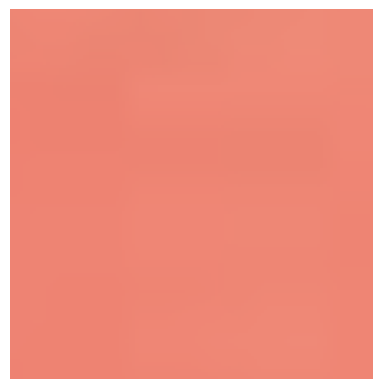

제품명: 데이지크_쥬시듀이틴트_러브코랄.png


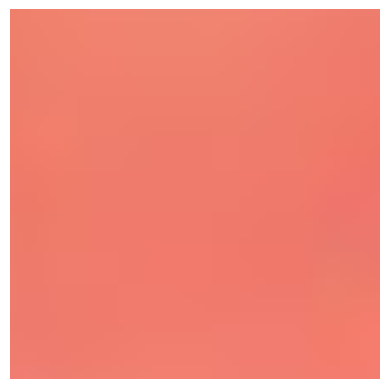

제품명: 코스노리_플로우웨이브틴트_코랄부케.png


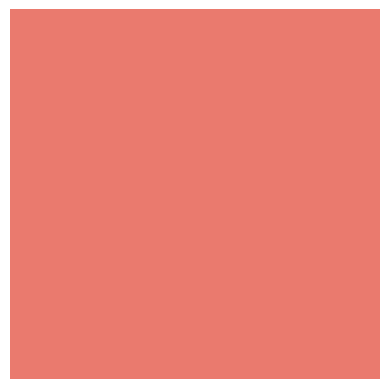

제품명: 데이지크_쥬시듀이틴트_무드망고.png


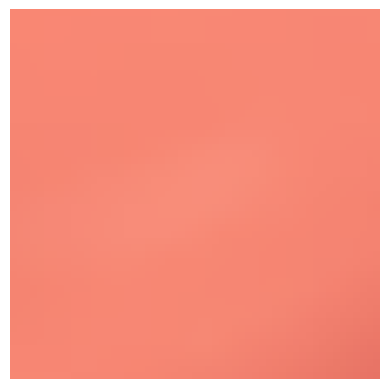

제품명: 웨이크메이크_듀이젤글로우틴트_버블리코랄.png


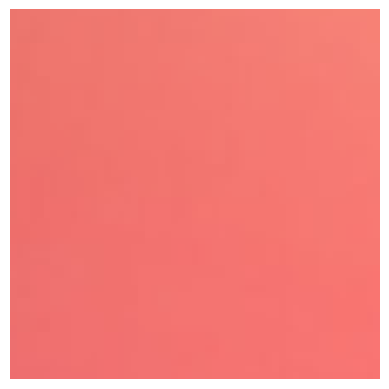

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 제품 추천 함수
def recommend_products(input_product, df, num_recommendations=5):
    try:
        df = calculate_rgb_similarity(input_product, df)
        df = calculate_formulation_tone_similarity(input_product, df)
        df = calculate_overall_similarity(df)

        recommendations = df[df['File Name'].str.lower() != input_product.lower()]
        recommended_products = recommendations[['File Name', 'Overall Similarity']].head(num_recommendations)

        for index, row in recommended_products.iterrows():
            print("제품명:", row['File Name'])
            image_path = f"/content/drive/MyDrive/oliveyoung_lip_color/{row['File Name']}"  # 이미지 파일의 경로
            img = mpimg.imread(image_path)
            plt.imshow(img)
            plt.axis('off')  # 축 제거
            plt.show()  # 이미지 출력

    except ValueError as e:
        print(e)

# 사용자 입력 받기
input_product = input("제품명을 입력하세요: ")

# 제품 추천 실행
recommend_products(input_product, df)